In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Library

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Muat Data

In [65]:
df_raw = pd.read_csv("data_imei.csv")
print("Jumlah data mentah :", len(df_raw))
print("Jumlah kolom       :", df_raw.shape[1])
df_raw.head()

Jumlah data mentah : 2464
Jumlah kolom       : 12


,#,Tipe,Biaya,Modal,DP Server,Sisa Server,Profit,Metode Pembayaran,Supplier,Status,Tanggal Transaksi,Tanggal Selesai
0,1,Tipe A,270000,230000,230000,0,40000,Transfer,Supplier B,Selesai,1 Juli 2025,2 Juli 2025
1,2,Tipe A,270000,230000,230000,0,40000,Transfer,Supplier B,Selesai,1 Juli 2025,2 Juli 2025
2,3,Tipe A,270000,230000,230000,0,40000,Transfer,Supplier B,Selesai,1 Juli 2025,2 Juli 2025
3,4,Tipe A,270000,230000,230000,0,40000,Transfer,Supplier B,Selesai,1 Juli 2025,2 Juli 2025
4,5,Tipe A,270000,230000,230000,0,40000,Transfer,Supplier B,Selesai,1 Juli 2025,2 Juli 2025


## Eksplorasi Data Awal


In [66]:
print("Distribusi Status Transaksi:")
print(df_raw["Status"].value_counts())
print("\nJumlah variasi penulisan nama pemasok (data mentah):", df_raw["Supplier"].nunique())

Distribusi Status Transaksi:
Status
Selesai        2460
Belum_lunas       4
Name: count, dtype: int64

Jumlah variasi penulisan nama pemasok (data mentah): 9


Korelasi Biaya vs Modal (r): 0.96


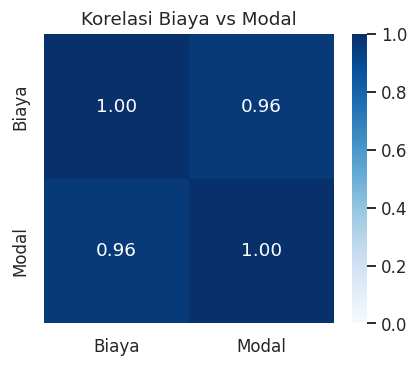

In [67]:
corr = df_raw[["Biaya", "Modal"]].corr()
print("Korelasi Biaya vs Modal (r):", round(corr.loc["Biaya", "Modal"], 2))

plt.figure(figsize=(4, 3.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Korelasi Biaya vs Modal")
plt.tight_layout()
plt.show()

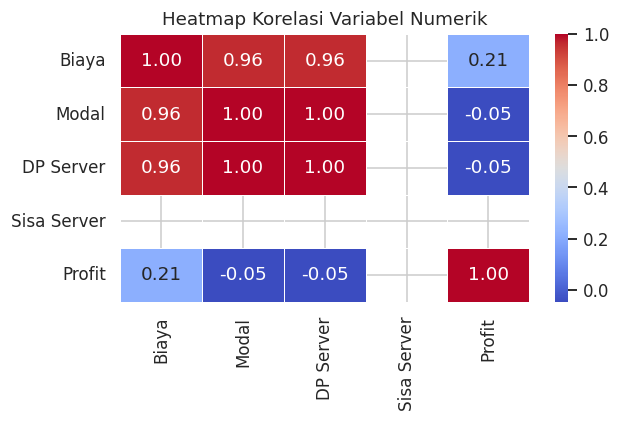

In [68]:
plt.figure(figsize=(6, 4))
corr = df_raw[['Biaya', 'Modal', 'DP Server', 'Sisa Server', 'Profit']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

## Pemrosesan Data

### Pembersihan Data

#### Normalisasi Penulisan Nama Pemasok

In [69]:
contoh_variasi = pd.DataFrame({
    "Nama Pemasok Setelah Normalisasi": [
        "PEMASOK A", "PEMASOK A", "PEMASOK A", "PEMASOK A",
        "PEMASOK B", "PEMASOK B", "PEMASOK B",
        "PEMASOK C", "PEMASOK C", "PEMASOK C",
    ],
    "Variasi Penulisan pada Data Mentah (Ilustrasi)": [
        "Pemasok A", "pemasok a", "PemasOk A ", "PEMASOK A",
        "Pemasok  B", "pemasok b", "PEMASOK B ",
        "Pemasok C", "PemasOk c ", "pemasok C",
    ],
})

contoh_variasi["Hasil normalize()"] = (
    contoh_variasi["Variasi Penulisan pada Data Mentah (Ilustrasi)"].str.upper().str.strip()
)
print("Ilustrasi Hasil Normalisasi Penulisan Nama Pemasok")
hasil_normalisasi = (
    contoh_variasi.groupby("Hasil normalize()")["Variasi Penulisan pada Data Mentah (Ilustrasi)"]
    .apply(lambda s: ", ".join(s))
    .reset_index()
    .rename(columns={"Hasil normalize()": "Nama Pemasok Setelah Normalisasi"})
)
hasil_normalisasi

Ilustrasi Hasil Normalisasi Penulisan Nama Pemasok


,Nama Pemasok Setelah Normalisasi,Variasi Penulisan pada Data Mentah (Ilustrasi)
0,PEMASOK B,Pemasok B
1,PEMASOK A,"Pemasok A, pemasok a, PemasOk A , PEMASOK A"
2,PEMASOK B,"pemasok b, PEMASOK B"
3,PEMASOK C,"Pemasok C, PemasOk c , pemasok C"


In [70]:
df = df_raw.copy()
df["Supplier_norm"] = df["Supplier"].str.upper().str.strip()

print(f"Jumlah variasi penulisan pada data mentah : {df['Supplier'].nunique()}")
print(f"Jumlah nama pemasok unik setelah normalisasi : {df['Supplier_norm'].nunique()}")

Jumlah variasi penulisan pada data mentah : 9
Jumlah nama pemasok unik setelah normalisasi : 9


#### Hapus Anomali & Filter Status

In [71]:
n_mentah = len(df)

anomali = df[df["Biaya"] <= 1000]
df = df[df["Biaya"] > 1000].copy()
n_setelah_anomali = len(df)

belum_selesai = df[df["Status"] != "Selesai"]
df = df[df["Status"] == "Selesai"].copy()
df = df.reset_index(drop=True)
n_bersih = len(df)

ringkasan_pembersihan = pd.DataFrame({
    "Tahap Pembersihan": [
        "Data mentah",
        "Penghapusan anomali (Biaya \u2264 Rp1.000)",
        "Penghapusan transaksi berstatus bukan \"Selesai\"",
    ],
    "Jumlah Data Dibuang": ["-", len(anomali), len(belum_selesai)],
    "Sisa Data": [n_mentah, n_setelah_anomali, n_bersih],
})
print("Ringkasan Hasil Pembersihan Data")
ringkasan_pembersihan

Ringkasan Hasil Pembersihan Data


,Tahap Pembersihan,Jumlah Data Dibuang,Sisa Data
0,Data mentah,-,2464
1,Penghapusan anomali (Biaya ≤ Rp1.000),2,2462
2,"Penghapusan transaksi berstatus bukan ""Selesai""",4,2458


#### Kelompokkan Pemasok Minor & Samarkan Nama


In [72]:
vc = df["Supplier_norm"].value_counts()
supplier_minor = vc[vc < 10].index.tolist()
print(f"Jumlah pemasok dengan frekuensi < 10 transaksi (digabung ke 'Lainnya'): {len(supplier_minor)}")

df["Supplier_clean"] = df["Supplier_norm"].apply(
    lambda x: "LAINNYA" if x in supplier_minor else x
)

supplier_order = df["Supplier_clean"].value_counts().index.tolist()
huruf = [chr(i) for i in range(ord("A"), ord("Z") + 1)]
idx = 0
supplier_map = {}
for s in supplier_order:
    if s == "LAINNYA":
        supplier_map[s] = "Supplier Lainnya"
    else:
        supplier_map[s] = f"Supplier {huruf[idx]}"
        idx += 1

df["Supplier_label"] = df["Supplier_clean"].map(supplier_map)

Jumlah pemasok dengan frekuensi < 10 transaksi (digabung ke 'Lainnya'): 1


In [73]:
distribusi_supplier = (
    df["Supplier_label"].value_counts()
    .rename_axis("Kategori Pemasok")
    .reset_index(name="Jumlah Transaksi")
)
distribusi_supplier["Persentase"] = (distribusi_supplier["Jumlah Transaksi"] / len(df) * 100).round(1).astype(str) + "%"
print("Distribusi Transaksi per Kategori Pemasok Setelah Pengelompokan dan Penyamaran")
distribusi_supplier

Distribusi Transaksi per Kategori Pemasok Setelah Pengelompokan dan Penyamaran


,Kategori Pemasok,Jumlah Transaksi,Persentase
0,Supplier A,1183,48.1%
1,Supplier B,710,28.9%
2,Supplier C,181,7.4%
3,Supplier D,162,6.6%
4,Supplier E,113,4.6%
5,Supplier F,50,2.0%
6,Supplier G,27,1.1%
7,Supplier H,23,0.9%
8,Supplier Lainnya,9,0.4%


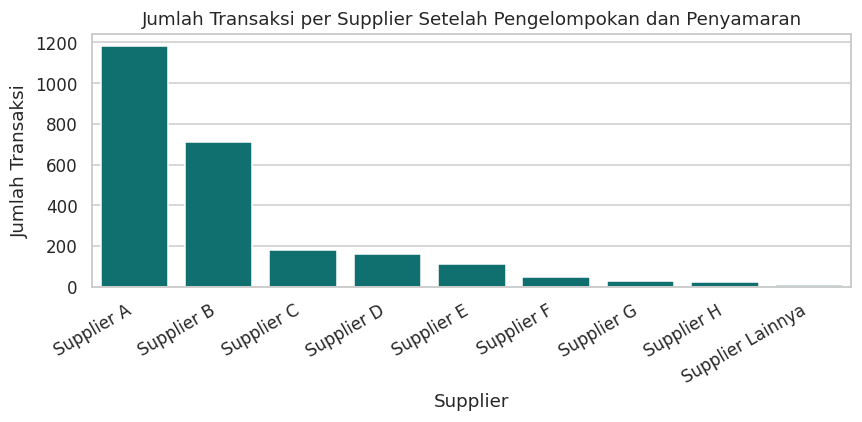

In [74]:
plt.figure(figsize=(8, 4))
order = distribusi_supplier.sort_values("Jumlah Transaksi", ascending=False)["Kategori Pemasok"]
sns.countplot(data=df, x="Supplier_label", order=order, color="teal")
plt.title("Jumlah Transaksi per Supplier Setelah Pengelompokan dan Penyamaran")
plt.xlabel("Supplier"); plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Seleksi Fitur

In [75]:
daftar_fitur = pd.DataFrame({
    "Fitur": ["Tipe layanan", "Biaya", "Supplier"],
    "Tipe Data": ["Kategorikal", "Numerik", "Kategorikal"],
})
print("Variabel yang Digunakan sebagai Fitur Prediktor")
daftar_fitur

Variabel yang Digunakan sebagai Fitur Prediktor


,Fitur,Tipe Data
0,Tipe layanan,Kategorikal
1,Biaya,Numerik
2,Supplier,Kategorikal


In [76]:
FITUR = ["Tipe", "Biaya", "Supplier_label"]
TARGET = "Modal"
df[FITUR + [TARGET]].sample(5, random_state=1)

,Tipe,Biaya,Supplier_label,Modal
1268,Tipe A,98000,Supplier A,75000
2269,Tipe A,90000,Supplier A,55000
1617,Tipe A,95000,Supplier B,65000
499,Tipe A,165000,Supplier E,125000
535,Tipe A,155000,Supplier B,135000


### Transformasi Data dengan Label Encoding

In [77]:
le_tipe = LabelEncoder()
le_sup = LabelEncoder()

df["Tipe_enc"] = le_tipe.fit_transform(df["Tipe"])
df["Supplier_enc"] = le_sup.fit_transform(df["Supplier_label"])

tipe_label_map = {kelas: f"Tipe {chr(65+i)}" for i, kelas in enumerate(le_tipe.classes_)}
df["Tipe_label"] = df["Tipe"].map(tipe_label_map)

mapping_encoding = pd.DataFrame(
    [("Tipe layanan", tipe_label_map[k], v) for k, v in zip(le_tipe.classes_, le_tipe.transform(le_tipe.classes_))] +
    [("Supplier", k, v) for k, v in zip(le_sup.classes_, le_sup.transform(le_sup.classes_))],
    columns=["Fitur", "Kategori", "Kode Numerik"],
)
print("Hasil Pemetaan Label Encoding pada Fitur Kategorikal")
mapping_encoding

Hasil Pemetaan Label Encoding pada Fitur Kategorikal


,Fitur,Kategori,Kode Numerik
0,Tipe layanan,Tipe A,0
1,Tipe layanan,Tipe B,1
2,Supplier,Supplier A,0
3,Supplier,Supplier B,1
4,Supplier,Supplier C,2
5,Supplier,Supplier D,3
6,Supplier,Supplier E,4
7,Supplier,Supplier F,5
8,Supplier,Supplier G,6
9,Supplier,Supplier H,7


In [78]:
sample_encoding = df[["Tipe_label", "Tipe_enc", "Supplier_label", "Supplier_enc", "Biaya"]].sample(
    5, random_state=7
).rename(columns={
    "Tipe_label": "Tipe (asli)",
    "Supplier_label": "Supplier (asli)",
    "Biaya": "Biaya (Rp)",
}).reset_index(drop=True)
print(" Hasil Transformasi Label Encoding pada Data Transaksi")
sample_encoding

 Hasil Transformasi Label Encoding pada Data Transaksi


,Tipe (asli),Tipe_enc,Supplier (asli),Supplier_enc,Biaya (Rp)
0,Tipe A,0,Supplier A,0,190000
1,Tipe A,0,Supplier A,0,125000
2,Tipe A,0,Supplier A,0,155000
3,Tipe A,0,Supplier A,0,175000
4,Tipe A,0,Supplier B,1,200000


### Pembagian Data Latih dan Data Uji

In [79]:
X = df[["Tipe_enc", "Biaya", "Supplier_enc"]]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pembagian_data = pd.DataFrame({
    "Jenis Data": ["Data latih (80%)", "Data uji (20%)", "Total"],
    "Jumlah": [len(X_train), len(X_test), len(X_train) + len(X_test)],
})
print("Pembagian Data Latih dan Data Uji")
pembagian_data

Pembagian Data Latih dan Data Uji


,Jenis Data,Jumlah
0,Data latih (80%),1966
1,Data uji (20%),492
2,Total,2458


### Normalisasi Skala Fitur

In [80]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

parameter_scaler = pd.DataFrame({
    "Fitur": ["Tipe_enc", "Biaya", "Supplier_enc"],
    "Rata-rata (\u03bc)": scaler.mean_.round(2),
    "Simpangan Baku (\u03c3)": scaler.scale_.round(2),
})
print("Parameter Standard Scaler yang Dihitung dari Data Latih")
parameter_scaler

Parameter Standard Scaler yang Dihitung dari Data Latih


,Fitur,Rata-rata (μ),Simpangan Baku (σ)
0,Tipe_enc,0.01,0.08
1,Biaya,"134,797.56","50,088.75"
2,Supplier_enc,1.04,1.51


In [81]:
idxs = X_train.index[:5]
before = X_train.loc[idxs].reset_index(drop=True)
after = pd.DataFrame(
    scaler.transform(X_train.loc[idxs]), columns=X_train.columns
).round(3).reset_index(drop=True)

sample_scaling = pd.concat([before, after.add_suffix(" (scaled)")], axis=1)
print("Contoh Hasil Normalisasi Data dengan Standard Scaler")
sample_scaling

Contoh Hasil Normalisasi Data dengan Standard Scaler


,Tipe_enc,Biaya,Supplier_enc,Tipe_enc (scaled),Biaya (scaled),Supplier_enc (scaled)
0,0,155000,0,-0.09,0.40,-0.69
1,0,125000,3,-0.09,-0.20,1.30
2,0,95000,1,-0.09,-0.80,-0.03
3,0,95000,0,-0.09,-0.80,-0.69
4,0,175000,2,-0.09,0.80,0.64


## 4. Pembangunan Model K-Nearest Neighbor

### 3.4.1 Penentuan Nilai K

In [82]:
k_values = list(range(3, 22, 2))
rows_performance_k = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)

    mae_k = mean_absolute_error(y_test, pred)
    rmse_k = np.sqrt(np.mean((y_test - pred) ** 2))
    mape_k = mean_absolute_percentage_error(y_test, pred) * 100
    r2_k = r2_score(y_test, pred)

    rows_performance_k.append({
        "K": k,
        "MAE (Rp)": round(mae_k, 2),
        "RMSE (Rp)": round(rmse_k, 2),
        "MAPE (%)": round(mape_k, 2),
        "R2": round(r2_k, 4),
    })

df_eval = pd.DataFrame(rows_performance_k).set_index("K")
print("Perbandingan Performa Model pada Setiap Nilai K")
df_eval

Perbandingan Performa Model pada Setiap Nilai K


,MAE (Rp),RMSE (Rp),MAPE (%),R2
K,,,,
3,"5,556.91","10,379.08",5.70,0.95
5,"5,301.22","10,181.72",5.42,0.95
7,"5,281.07","10,290.61",5.45,0.95
9,"5,245.26","10,455.30",5.39,0.95
11,"5,216.37","10,748.68",5.38,0.95
13,"5,279.24","11,009.40",5.45,0.95
15,"5,380.49","11,235.55",5.56,0.94
17,"5,483.86","11,476.15",5.65,0.94
19,"5,514.12","11,588.65",5.65,0.94


In [83]:
best_k_rmse = int(df_eval["RMSE (Rp)"].idxmin())
best_k_r2 = int(df_eval["R2"].idxmax())

print(f"K dengan RMSE terendah : {best_k_rmse}")
print(f"K dengan R2 tertinggi  : {best_k_r2}")

assert best_k_rmse == best_k_r2, "RMSE terendah dan R2 tertinggi tidak di K yang sama, tinjau ulang kriteria."

best_k = best_k_rmse
print(f"\n==> Nilai K yang dipilih secara otomatis: K = {best_k}")

K dengan RMSE terendah : 5
K dengan R2 tertinggi  : 5

==> Nilai K yang dipilih secara otomatis: K = 5


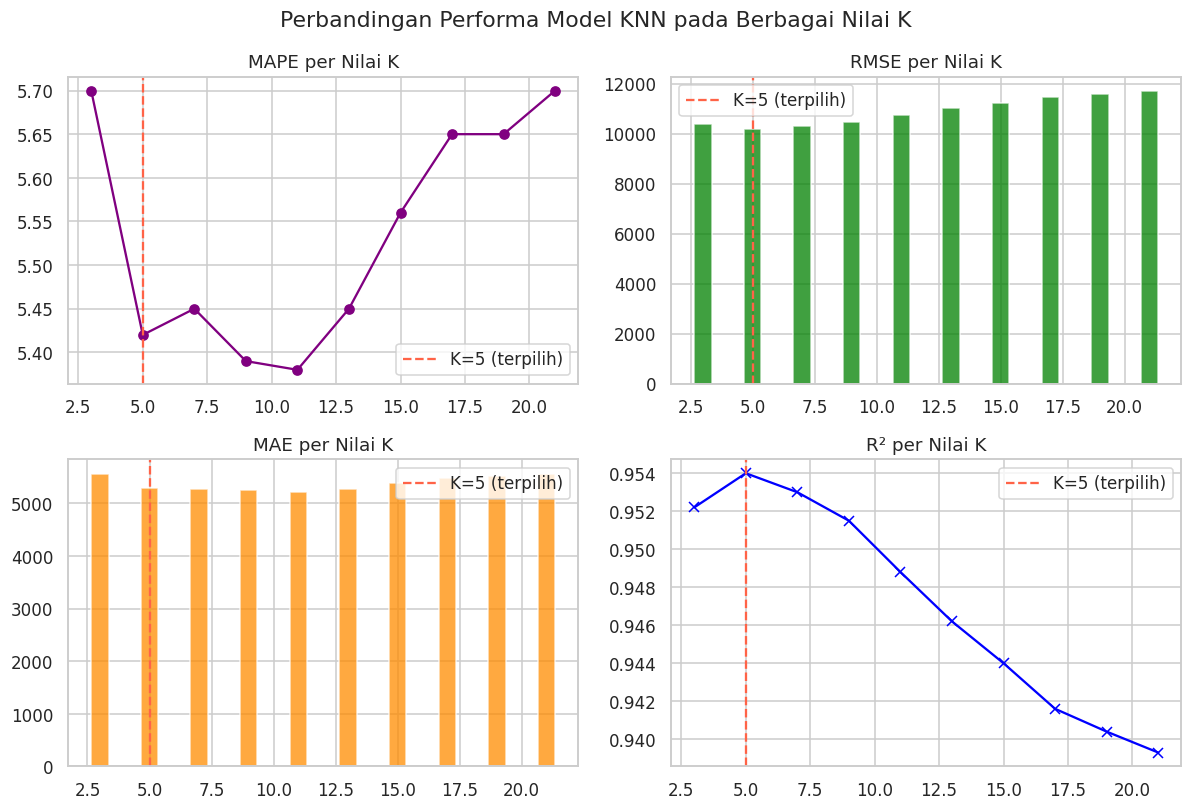

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

axes[0,0].plot(df_eval.index, df_eval["MAPE (%)"], marker="o", color="purple")
axes[0,0].axvline(best_k, color="tomato", linestyle="--", label=f"K={best_k} (terpilih)")
axes[0,0].set_title("MAPE per Nilai K"); axes[0,0].legend()

axes[0,1].bar(df_eval.index, df_eval["RMSE (Rp)"], color="green", alpha=0.75, width=0.7)
axes[0,1].axvline(best_k, color="tomato", linestyle="--", label=f"K={best_k} (terpilih)")
axes[0,1].set_title("RMSE per Nilai K"); axes[0,1].legend()

axes[1,0].bar(df_eval.index, df_eval["MAE (Rp)"], color="darkorange", alpha=0.75, width=0.7)
axes[1,0].axvline(best_k, color="tomato", linestyle="--", label=f"K={best_k} (terpilih)")
axes[1,0].set_title("MAE per Nilai K"); axes[1,0].legend()

axes[1,1].plot(df_eval.index, df_eval["R2"], marker="x", color="blue")
axes[1,1].axvline(best_k, color="tomato", linestyle="--", label=f"K={best_k} (terpilih)")
axes[1,1].set_title("R\u00b2 per Nilai K"); axes[1,1].legend()

plt.suptitle("Perbandingan Performa Model KNN pada Berbagai Nilai K")
plt.tight_layout()
plt.show()

### Pelatihan Model Final

In [85]:
knn_model = KNeighborsRegressor(n_neighbors=best_k)
knn_model.fit(X_train_sc, y_train)
print(f"Model KNN final dilatih dengan K = {best_k} pada {len(X_train)} data latih.")

Model KNN final dilatih dengan K = 5 pada 1966 data latih.


## Evaluasi

In [86]:
y_pred = knn_model.predict(X_test_sc)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
akurasi = 100 - mape
r2 = r2_score(y_test, y_pred)

ringkasan_metrik = pd.DataFrame({
    "Metrik": ["MAE (Rp)", "RMSE (Rp)", "MAPE (%)", "R2"],
    "Nilai": [round(mae, 2), round(rmse, 2), round(mape, 2), round(r2, 4)],
})
print(f"Ringkasan Evaluasi Model KNN Final (K = {best_k})")
ringkasan_metrik

Ringkasan Evaluasi Model KNN Final (K = 5)


,Metrik,Nilai
0,MAE (Rp),"5,301.22"
1,RMSE (Rp),"10,181.72"
2,MAPE (%),5.42
3,R2,0.95


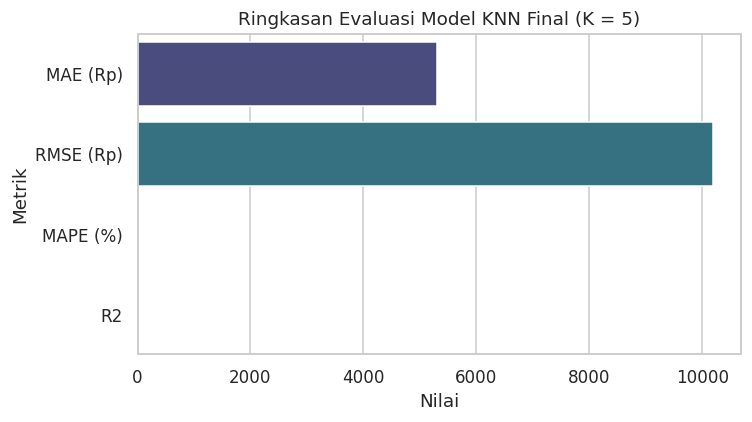

Rata-rata profit per transaksi Toko X : Rp30,873
MAE setara 17.2% dari rata-rata profit tersebut.


In [87]:
plt.figure(figsize=(7, 4))
sns.barplot(data=ringkasan_metrik, x="Nilai", y="Metrik", hue="Metrik",
            palette="viridis", legend=False, orient="h")
plt.title(f"Ringkasan Evaluasi Model KNN Final (K = {best_k})")
plt.tight_layout()
plt.show()

rata_rata_profit = (df["Biaya"] - df["Modal"]).mean()
print(f"Rata-rata profit per transaksi Toko X : Rp{rata_rata_profit:,.0f}")
print(f"MAE setara {mae / rata_rata_profit * 100:.1f}% dari rata-rata profit tersebut.")

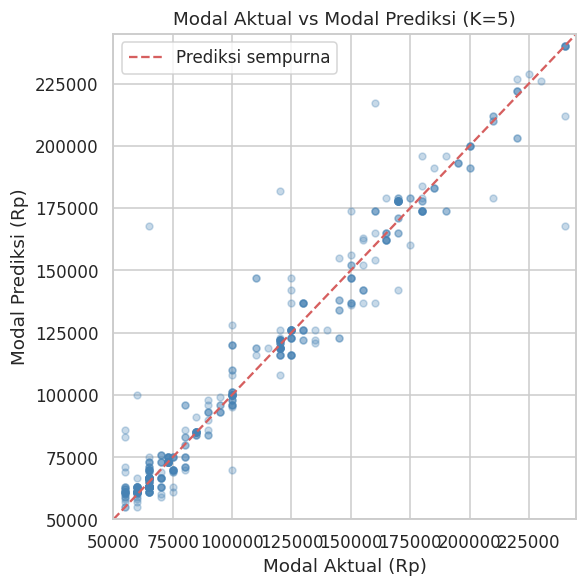

In [88]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, y_pred, alpha=0.3, s=20, color="steelblue")
lims = [min(y_test.min(), y_pred.min()) - 5000, max(y_test.max(), y_pred.max()) + 5000]
plt.plot(lims, lims, "r--", label="Prediksi sempurna")
plt.xlim(lims); plt.ylim(lims)
plt.title(f"Modal Aktual vs Modal Prediksi (K={best_k})")
plt.xlabel("Modal Aktual (Rp)"); plt.ylabel("Modal Prediksi (Rp)")
plt.legend(); plt.tight_layout()
plt.show()

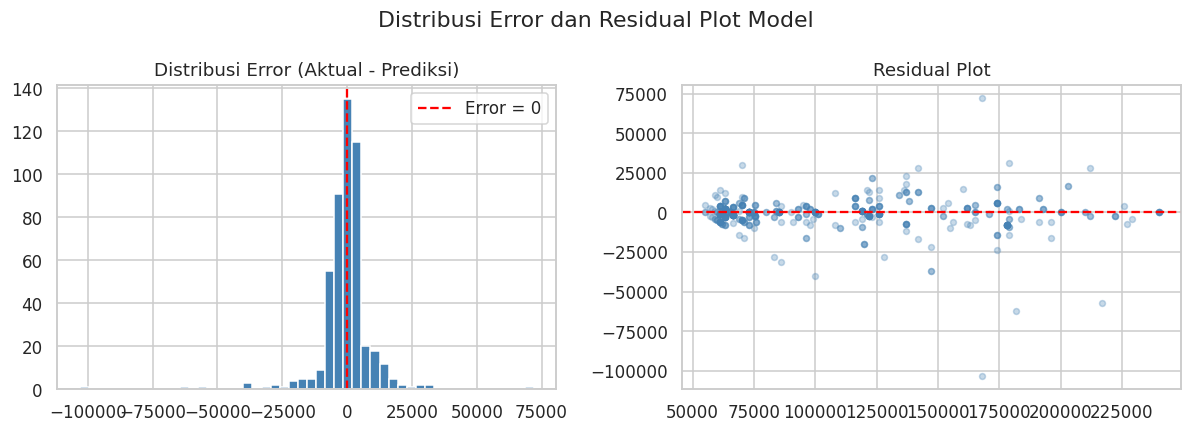

Rata-rata error   : Rp-578
Simpangan baku    : Rp10,165
Error <= Rp5.000  : 69.3% data uji
Error <= Rp10.000 : 88.8% data uji


In [89]:
errors = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(errors, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", label="Error = 0")
axes[0].set_title("Distribusi Error (Aktual - Prediksi)"); axes[0].legend()

axes[1].scatter(y_pred, errors, alpha=0.3, s=15, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residual Plot")

plt.suptitle("Distribusi Error dan Residual Plot Model")
plt.tight_layout()
plt.show()

print(f"Rata-rata error   : Rp{errors.mean():,.0f}")
print(f"Simpangan baku    : Rp{errors.std():,.0f}")
print(f"Error <= Rp5.000  : {(np.abs(errors) <= 5000).mean()*100:.1f}% data uji")
print(f"Error <= Rp10.000 : {(np.abs(errors) <= 10000).mean()*100:.1f}% data uji")

## 6. Simulasi Penerapan pada Studi Kasus

In [90]:
tipe_input_asli = df["Tipe"].mode()[0]
biaya_input = 120000

hasil_simulasi = []
for sup_label in sorted(le_sup.classes_):
    tipe_enc = le_tipe.transform([tipe_input_asli])[0]
    sup_enc = le_sup.transform([sup_label])[0]

    fitur_baru = pd.DataFrame(
        [[tipe_enc, biaya_input, sup_enc]], columns=["Tipe_enc", "Biaya", "Supplier_enc"]
    )
    fitur_baru_sc = scaler.transform(fitur_baru)
    modal_estimasi = knn_model.predict(fitur_baru_sc)[0]
    profit_estimasi = biaya_input - modal_estimasi

    hasil_simulasi.append({
        "Supplier": sup_label,
        "Estimasi Modal (Rp)": round(modal_estimasi),
        "Estimasi Profit (Rp)": round(profit_estimasi),
    })

df_simulasi = pd.DataFrame(hasil_simulasi).sort_values(
    "Estimasi Profit (Rp)", ascending=False
).reset_index(drop=True)
df_simulasi.index = df_simulasi.index + 1
df_simulasi.index.name = "Peringkat"
print(f"Simulasi Estimasi Profit per Supplier untuk Tipe A, Biaya Rp{biaya_input:,}")
df_simulasi

Simulasi Estimasi Profit per Supplier untuk Tipe A, Biaya Rp120,000


,Supplier,Estimasi Modal (Rp),Estimasi Profit (Rp)
Peringkat,,,
1,Supplier G,66000,54000
2,Supplier H,70000,50000
3,Supplier F,73000,47000
4,Supplier C,75200,44800
5,Supplier E,81000,39000
6,Supplier D,85000,35000
7,Supplier A,86000,34000
8,Supplier B,90000,30000
9,Supplier Lainnya,105000,15000


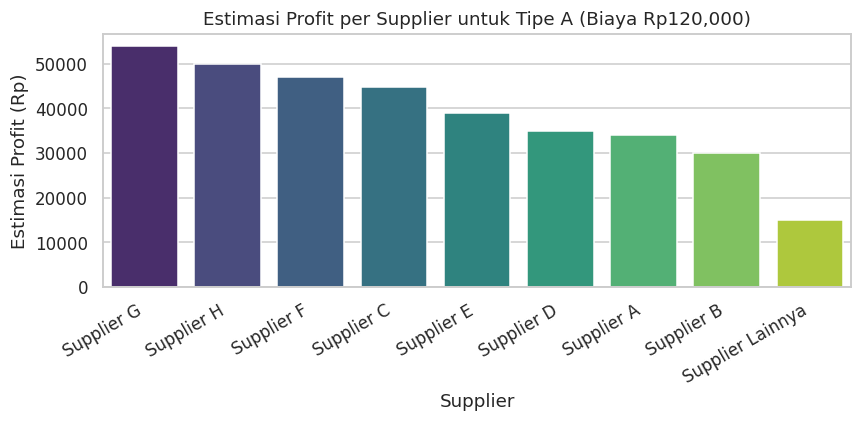

Rekomendasi sistem: Supplier G dengan estimasi profit Rp54,000


In [91]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df_simulasi, x="Supplier", y="Estimasi Profit (Rp)",
            hue="Supplier", palette="viridis", legend=False)
plt.title(f"Estimasi Profit per Supplier untuk Tipe A (Biaya Rp{biaya_input:,})")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

rekomendasi = df_simulasi.iloc[0]
print(f"Rekomendasi sistem: {rekomendasi['Supplier']} "
      f"dengan estimasi profit Rp{rekomendasi['Estimasi Profit (Rp)']:,.0f}")